<a href="https://colab.research.google.com/github/ABHISHEkabiii/Automatic-Image-Captioning/blob/main/Automatic_Image_Captioning_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Automatic Image Captioning
### CNN (VGG16) + LSTM | Flickr8k | BLEU Evaluation


## Step 0 — Dataset Download

In [6]:
#  Paste your Kaggle credentials
KAGGLE_USERNAME = "pro"
KAGGLE_KEY      = "KGAT_05b58d5d74418be2738aa30749027a40"

import os
os.environ['KAGGLE_USERNAME'] = KAGGLE_USERNAME
os.environ['KAGGLE_KEY']      = KAGGLE_KEY

!pip install kaggle --quiet
!kaggle datasets download -d adityajn105/flickr8k
!unzip -q flickr8k.zip -d flickr8k
print(' Dataset ready')
!ls flickr8k/

Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0
100% 1.04G/1.04G [00:05<00:00, 213MB/s]

 Dataset ready
captions.txt  Images


## Step 1 — Imports

In [7]:
import re, pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, Add
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from nltk.translate.bleu_score import corpus_bleu
import nltk
nltk.download('punkt', quiet=True)

print(f'   TensorFlow {tf.__version__}')
print(f'   GPU: {len(tf.config.list_physical_devices("GPU")) > 0}')

   TensorFlow 2.19.0
   GPU: True


In [8]:
# Auto-detect paths
BASE_DIR = 'flickr8k'
IMAGES_DIR = next(
    os.path.join(BASE_DIR, d)
    for d in ['Images', 'images']
    if os.path.exists(os.path.join(BASE_DIR, d))
)
CAPTIONS_FILE = os.path.join(BASE_DIR, 'captions.txt')
print(f'Images : {IMAGES_DIR} ({len(os.listdir(IMAGES_DIR))} files)')
print(f'Captions: {CAPTIONS_FILE}')

Images : flickr8k/Images (8091 files)
Captions: flickr8k/captions.txt


## Step 2 — VGG16 Feature Extraction

In [9]:
vgg = VGG16(weights='imagenet', include_top=True)
vgg = Model(inputs=vgg.inputs, outputs=vgg.layers[-2].output)  # 4096-dim
print('VGG16 output shape:', vgg.output_shape)

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
VGG16 output shape: (None, 4096)


In [10]:
def extract_features(images_dir):
    features = {}
    files = [f for f in os.listdir(images_dir)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    for fname in tqdm(files, desc='VGG16 extraction'):
        try:
            img  = load_img(os.path.join(images_dir, fname), target_size=(224, 224))
            arr  = preprocess_input(np.expand_dims(img_to_array(img), 0))
            feat = vgg.predict(arr, verbose=0)  # (1, 4096)
            features[fname.split('.')[0]] = feat
        except Exception as e:
            print(f'Skip {fname}: {e}')
    return features

print('Extracting features (~10-15 min on GPU)...')
features = extract_features(IMAGES_DIR)
pickle.dump(features, open('features.pkl', 'wb'))
print(f'✅ {len(features)} images extracted & saved')

Extracting features (~10-15 min on GPU)...


VGG16 extraction: 100%|██████████| 8091/8091 [13:15<00:00, 10.17it/s]


✅ 8091 images extracted & saved


## Step 3 — Load & Preprocess Captions

In [11]:
def load_captions(path):
    mapping = {}
    with open(path) as f:
        for line in f.readlines()[1:]:
            line = line.strip()
            if not line: continue
            img, cap = line.split(',', 1)
            img_id = img.split('.')[0]
            mapping.setdefault(img_id, []).append(cap.strip())
    return mapping

def preprocess_captions(mapping):
    for img_id, caps in mapping.items():
        mapping[img_id] = [
            'startseq ' +
            ' '.join(w for w in
                re.sub(r'\s+', ' ',
                re.sub(r'[^a-z\s]', '',
                cap.lower())).strip().split() if len(w) > 1) +
            ' endseq'
            for cap in caps
        ]
    return mapping

mapping = preprocess_captions(load_captions(CAPTIONS_FILE))
sid = list(mapping.keys())[0]
print(f'Sample [{sid}]:')
[print(' ', c) for c in mapping[sid]]

Sample [1000268201_693b08cb0e]:
  startseq child in pink dress is climbing up set of stairs in an entry way endseq
  startseq girl going into wooden building endseq
  startseq little girl climbing into wooden playhouse endseq
  startseq little girl climbing the stairs to her playhouse endseq
  startseq little girl in pink dress going into wooden cabin endseq


[None, None, None, None, None]

In [12]:
# Train / test split
all_ids = list(set(mapping) & set(features))
np.random.seed(42); np.random.shuffle(all_ids)
split     = int(0.9 * len(all_ids))
train_ids = all_ids[:split]
test_ids  = all_ids[split:]
print(f'Train: {len(train_ids)}  |  Test: {len(test_ids)}')

# Tokenizer
train_caps = [c for i in train_ids for c in mapping[i]]
tokenizer  = Tokenizer(oov_token='<unk>')
tokenizer.fit_on_texts(train_caps)
vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(c.split()) for c in train_caps)
print(f'Vocab: {vocab_size}  |  Max length: {max_length}')
pickle.dump(tokenizer, open('tokenizer.pkl', 'wb'))

Train: 7281  |  Test: 810
Vocab: 8366  |  Max length: 34


## Step 4 — Build Model

In [13]:
def build_model(vocab_size, max_length):
    # Image feature branch
    img_in  = Input(shape=(4096,))
    img_out = Dropout(0.4)(img_in)
    img_out = Dense(256, activation='relu')(img_out)

    # Sequence branch
    seq_in  = Input(shape=(max_length,))
    seq_out = Embedding(vocab_size, 256, mask_zero=True)(seq_in)
    seq_out = Dropout(0.4)(seq_out)
    # We set use_cudnn=False to support the masking/padding provided by Keras
    seq_out = LSTM(256, use_cudnn=False)(seq_out)

    # Merge branches
    merged  = Add()([img_out, seq_out])
    merged  = Dense(256, activation='relu')(merged)
    out     = Dense(vocab_size, activation='softmax')(merged)

    model = Model([img_in, seq_in], out)
    model.compile(loss='categorical_crossentropy', optimizer='adam')
    return model

model = build_model(vocab_size, max_length)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 34)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 4096)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 34, 256)   │  2,141,696 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 4096)      │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 34, 256)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 34)        │          0 │ input_layer_2[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │  1,048,832 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    525,312 │ dropout_1[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ dense[0][0],      │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8366)      │  2,150,062 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,931,694 (22.63 MB)

 Trainable params: 5,931,694 (22.63 MB)

 Non-trainable params: 0 (0.00 B)

## Step 5 — Train ✅ (Fixed: LSTM configured to support masking)

In [14]:
EPOCHS     = 20
BATCH_SIZE = 32

total_samples = sum(
    sum(len(c.split()) - 1 for c in mapping[i])
    for i in train_ids
)
steps_per_epoch = total_samples // BATCH_SIZE

def sample_generator():
    while True:
        for img_id in train_ids:
            feat = features[img_id][0].astype(np.float32)
            for cap in mapping[img_id]:
                seq = tokenizer.texts_to_sequences([cap])[0]
                for i in range(1, len(seq)):
                    in_seq  = pad_sequences(
                                  [seq[:i]], maxlen=max_length,
                                  padding='post' # Changed to post-padding for better compatibility
                              )[0].astype(np.int32)
                    out_word = to_categorical(
                                   [seq[i]], num_classes=vocab_size
                               )[0].astype(np.float32)
                    yield (feat, in_seq), out_word

train_dataset = tf.data.Dataset.from_generator(
    sample_generator,
    output_signature=(
        (
            tf.TensorSpec(shape=(4096,),       dtype=tf.float32),
            tf.TensorSpec(shape=(max_length,), dtype=tf.int32),
        ),
        tf.TensorSpec(shape=(vocab_size,),     dtype=tf.float32),
    )
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

checkpoint = ModelCheckpoint(
    'best_model.keras', monitor='loss',
    save_best_only=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='loss', factor=0.5, patience=2, verbose=1
)

history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    callbacks=[checkpoint, reduce_lr],
    verbose=1
)

Epoch 1/20
11624/11624 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 5.0774
Epoch 1: loss improved from None to 4.62496, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
11624/11624 ━━━━━━━━━━━━━━━━━━━━ 236s 20ms/step - loss: 4.6250 - learning_rate: 0.0010
Epoch 2/20
11624/11624 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 4.0616
Epoch 2: loss improved from 4.62496 to 3.94878, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
11624/11624 ━━━━━━━━━━━━━━━━━━━━ 228s 20ms/step - loss: 3.9488 - learning_rate: 0.0010
Epoch 3/20
11624/11624 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 3.8109
Epoch 3: loss improved from 3.94878 to 3.73961, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
11624/11624 ━━━━━━━━━━━━━━━━━━━━ 230s 20ms/step - loss: 3.7396 - learning_rate: 0.0010
Epoch 4/20
11624/11624 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 3.6578
Epoch 4: loss improved from 3.73961 to 3.62144, saving 

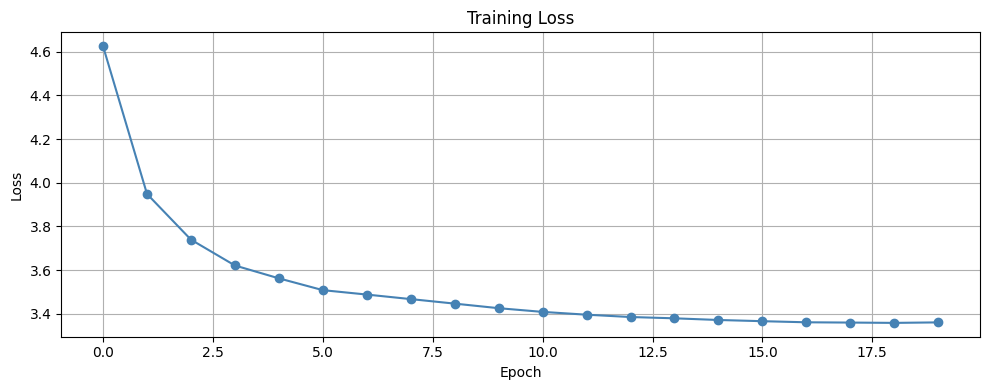

In [18]:
import matplotlib.pyplot as plt

if 'history' in globals():
    plt.figure(figsize=(10, 4))
    plt.plot(history.history['loss'], marker='o', color='steelblue')
    plt.title('Training Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.grid(True); plt.tight_layout(); plt.show()
else:
    print('Training history not found. Please ensure the training cell has finished executing.')

## Step 6 — Evaluate & Show Predictions

In [19]:
from tensorflow.keras.models import load_model
import os

model_path = 'best_model.keras'
if os.path.exists(model_path):
    model = load_model(model_path)
    print('✅ Best model loaded from disk')
else:
    print('⚠️ best_model.keras not found. Using the model instance currently in memory (if available).')

def generate_caption(model, tokenizer, feature, max_length):
    in_text = 'startseq'
    for _ in range(max_length):
        # Padding MUST match the training configuration (post)
        seq  = pad_sequences(
                   [tokenizer.texts_to_sequences([in_text])[0]],
                   maxlen=max_length,
                   padding='post')
        yhat = model.predict([feature, seq], verbose=0)
        word = tokenizer.index_word.get(np.argmax(yhat))
        if not word or word == 'endseq':
            break
        in_text += ' ' + word
    return in_text.replace('startseq ', '').strip()

✅ Best model loaded from disk


In [20]:
actual, predicted = [], []
for img_id in tqdm(test_ids, desc='BLEU eval'):
    refs = [c.replace('startseq ','').replace(' endseq','').split()
            for c in mapping[img_id]]
    cap  = generate_caption(model, tokenizer, features[img_id], max_length)
    actual.append(refs)
    predicted.append(cap.split())

print('\n📊 BLEU Scores:')
print(f'  BLEU-1: {corpus_bleu(actual, predicted, weights=(1,0,0,0)):.4f}')
print(f'  BLEU-2: {corpus_bleu(actual, predicted, weights=(.5,.5,0,0)):.4f}')
print(f'  BLEU-3: {corpus_bleu(actual, predicted, weights=(.33,.33,.33,0)):.4f}')
print(f'  BLEU-4: {corpus_bleu(actual, predicted, weights=(.25,.25,.25,.25)):.4f}')

BLEU eval: 100%|██████████| 810/810 [11:28<00:00,  1.18it/s]



📊 BLEU Scores:
  BLEU-1: 0.4207
  BLEU-2: 0.1986
  BLEU-3: 0.0868
  BLEU-4: 0.0392


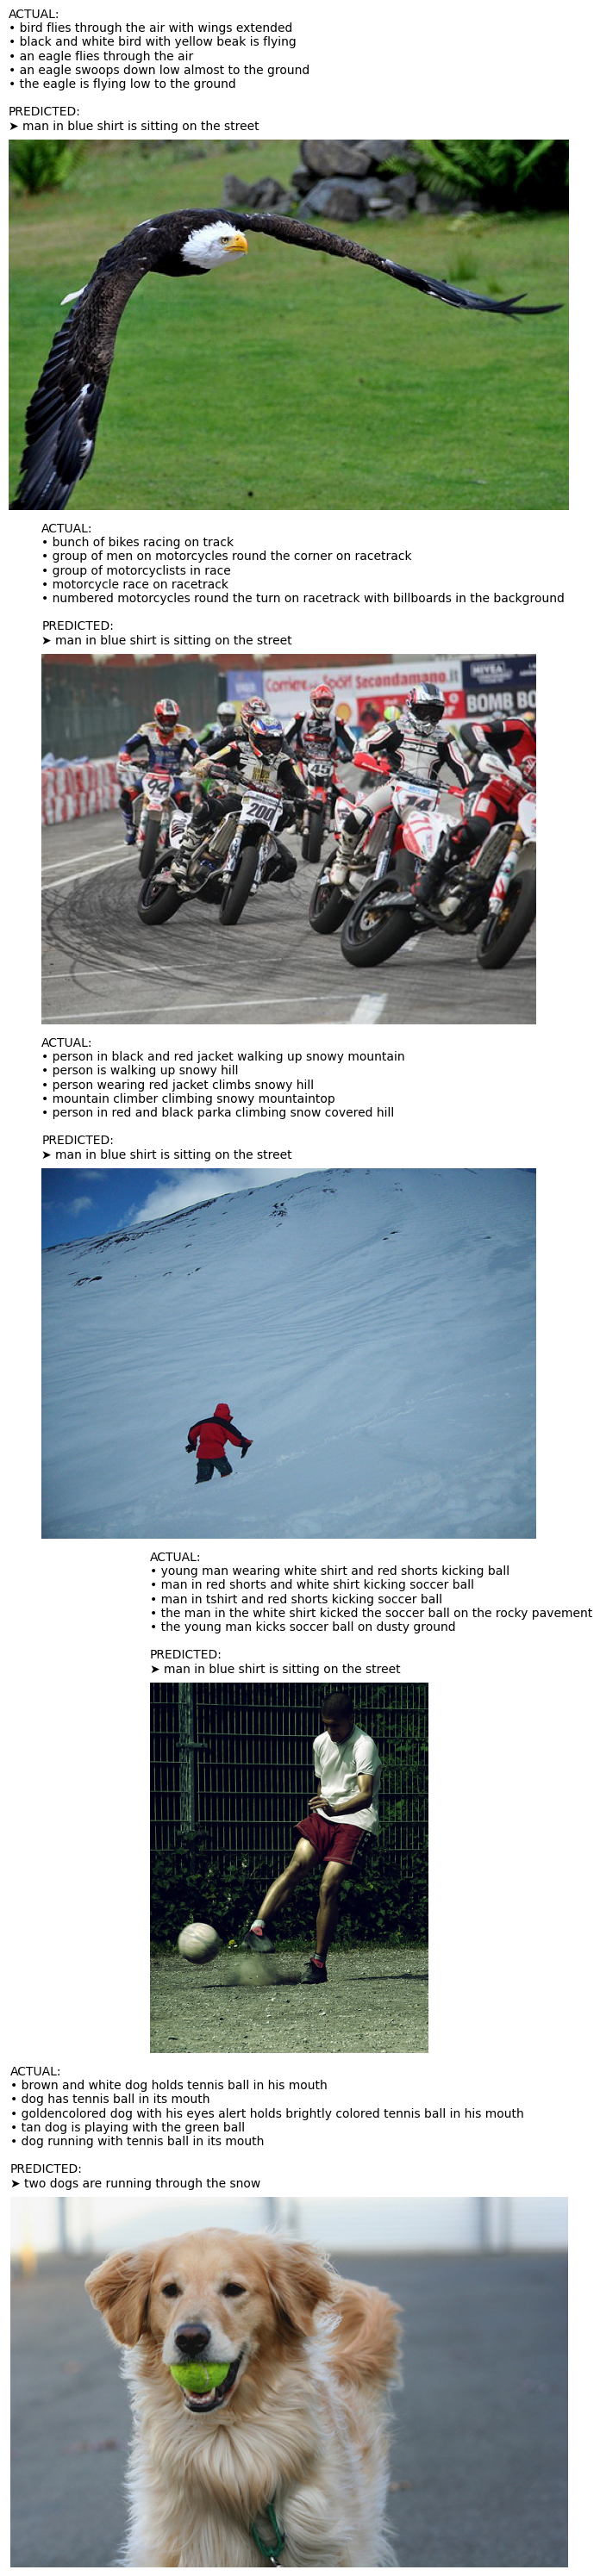

✅ Saved predictions.png


In [21]:
# Show 5 test predictions
sample_ids = np.random.choice(test_ids, 5, replace=False)
fig, axes  = plt.subplots(5, 1, figsize=(10, 30))

for ax, img_id in zip(axes, sample_ids):
    cap  = generate_caption(model, tokenizer, features[img_id], max_length)
    refs = [c.replace('startseq ','').replace(' endseq','') for c in mapping[img_id]]
    ax.imshow(mpimg.imread(os.path.join(IMAGES_DIR, img_id + '.jpg')))
    ax.axis('off')
    ax.set_title(
        'ACTUAL:\n' + '\n'.join(f'• {r}' for r in refs) +
        f'\n\nPREDICTED:\n➤ {cap}',
        fontsize=10, loc='left', pad=8
    )

plt.tight_layout()
plt.savefig('predictions.png', bbox_inches='tight', dpi=100)
plt.show()
print('✅ Saved predictions.png')

Upload any image:


Saving aura.png to aura.png


/tmp/ipykernel_6733/3067807346.py:15: UserWarning: Glyph 128221 (\N{MEMO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128221 (\N{MEMO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


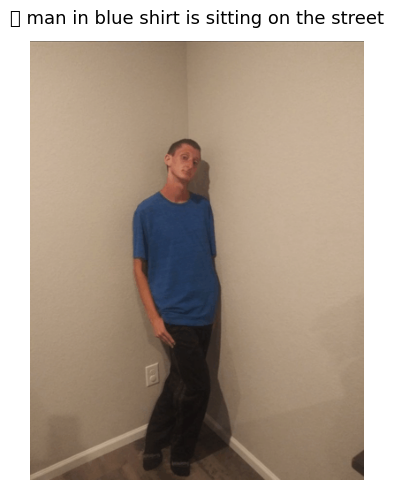

Caption: man in blue shirt is sitting on the street


In [22]:
# Test on your own image
from google.colab import files
print('Upload any image:')
uploaded = files.upload()

for fname in uploaded:
    img  = load_img(fname, target_size=(224, 224))
    arr  = preprocess_input(np.expand_dims(img_to_array(img), 0))
    feat = vgg.predict(arr, verbose=0)
    cap  = generate_caption(model, tokenizer, feat, max_length)
    plt.figure(figsize=(7, 5))
    plt.imshow(mpimg.imread(fname))
    plt.axis('off')
    plt.title(f'📝 {cap}', fontsize=13, pad=12)
    plt.tight_layout(); plt.show()
    print('Caption:', cap)